# Step 1: Stommel's model and its equilibria

Can a simple two-box ocean have more than one steady circulation for the same forcing? In this notebook I find the equilibria of Stommel's (1961) model, classify their stability, and integrate the model from 10 starting states to see which state each one ends in.

In [1]:
%matplotlib inline

import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import sys
sys.path.append("../src")   # models.py lives in the project's src/ folder

from models import (stommel_flow, stommel_equilibrium_mismatch,
                    stommel_state_from_f, stommel_jacobian,
                    classify_eigenvalues, stommel_run_euler)

In [2]:
# Parameters 
R = 2.0              # how strongly salinity affects density, relative to temperature
DELTA = 1.0 / 6.0    # salinity relaxes 6 times slower than temperature
LAM = 1.0 / 5.0      # flow resistance: a larger lambda means a weaker flow for the same density difference

F_MIN = -2.0         # range of flow strengths f to search for equilibria
F_MAX = 1.5
N_SCAN = 3501        # points in the f scan (fine enough not to miss a crossing)

DT = 0.002           # Euler time step; small because the flow is fast (|f| up to ~10) far from equilibrium
T_END = 60.0         # long enough for every path to settle (checked by the dt test)

STOMMEL_F = [-1.1, -0.30, 0.23]                         # values read off Stommel's hand-drawn graph
STOMMEL_TYPES = ["stable node", "saddle", "stable spiral"]

FIG_DIR = "../figures"

os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
# 1. Stommel's graphical method: both sides of the equilibrium equation
f_scan = np.linspace(F_MIN, F_MAX, N_SCAN)
left_side = LAM * f_scan                       # straight line lambda*f
right_side = np.zeros(N_SCAN)                  # density difference at steady state
for i in range(N_SCAN):
    f = f_scan[i]
    right_side[i] = -1.0 / (1.0 + abs(f)) + R * DELTA / (DELTA + abs(f))

Each place the two sides cross is an equilibrium. I look for sign changes of their difference, then refine each crossing with `brentq`, which is guaranteed to converge once it has an interval with a sign change.

In [4]:
# 2. Find each crossing: look for a sign change, then refine with brentq
# brentq needs an interval where the function changes sign. It is guaranteed to converge, unlike Newton's method, which can jump away from the root.
mismatch = right_side - left_side
f_equilibria = []
for i in range(N_SCAN - 1):
    if mismatch[i] * mismatch[i + 1] < 0:
        root = brentq(stommel_equilibrium_mismatch, f_scan[i], f_scan[i + 1],
                      args=(R, DELTA, LAM), xtol=1e-12)
        f_equilibria.append(root)

To classify each equilibrium, I compute the 2x2 Jacobian by finite differences and look at its eigenvalues. They tell me whether a small nudge grows or dies away, and whether it spirals.

In [5]:
# 3. Classify each equilibrium from the eigenvalues of the Jacobian
T_eq = []
S_eq = []
types = []
eigs_all = []
for f in f_equilibria:
    T, S = stommel_state_from_f(f, DELTA)
    J = stommel_jacobian(T, S, R, DELTA, LAM)
    eigs = np.linalg.eigvals(J)
    T_eq.append(T)
    S_eq.append(S)
    eigs_all.append(eigs)
    types.append(classify_eigenvalues(eigs))

I integrate with forward Euler from 10 starting states and record the final flow. Inside the same loop I rerun each path with dt/2. I compare both the end states and the whole paths, because Euler's end states agree for any dt.

In [6]:
# 4. Time integration from many starting points
# Corners and edge midpoints of the unit square, plus two points in between,
# so we sample both sides of the saddle.
starts = [(0.0, 0.0), (0.5, 0.0), (1.0, 0.0), (1.0, 0.5), (1.0, 1.0),
          (0.5, 1.0), (0.0, 1.0), (0.0, 0.5), (0.6, 0.4), (0.9, 0.6)]   # (S0, T0)

paths = []
end_f = []
max_diff_dt = 0.0
max_path_diff_dt = 0.0
for (S0, T0) in starts:
    T_path, S_path = stommel_run_euler(T0, S0, R, DELTA, LAM, DT, T_END)
    paths.append((S_path, T_path))
    end_f.append(stommel_flow(T_path[-1], S_path[-1], R, LAM))

    # Same run with half the time step. If the end states agree, the answer
    # comes from the equations, not from the numerical method.
    T_half, S_half = stommel_run_euler(T0, S0, R, DELTA, LAM, DT / 2, T_END)
    diff = max(abs(T_path[-1] - T_half[-1]), abs(S_path[-1] - S_half[-1]))
    max_diff_dt = max(max_diff_dt, diff)

    # The end states would agree for any dt: an Euler fixed point satisfies
    # dt*F(x) = 0, which is exactly F(x) = 0. So we also compare the whole
    # path at the same times (every second point of the dt/2 run).
    path_diff = max(np.max(np.abs(T_path - T_half[::2])),
                    np.max(np.abs(S_path - S_half[::2])))
    max_path_diff_dt = max(max_path_diff_dt, path_diff)

This figure shows the graphical method: the two sides of the equilibrium equation and their three crossings.

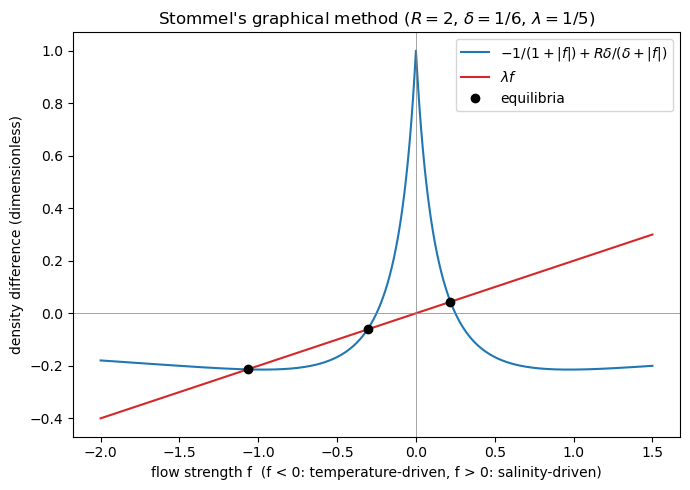

In [7]:
# 5. Figure 1: graphical method
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(f_scan, right_side, color="tab:blue",
        label=r"$-1/(1+|f|) + R\delta/(\delta+|f|)$")
ax.plot(f_scan, left_side, color="tab:red", label=r"$\lambda f$")
ax.plot(f_equilibria, [LAM * f for f in f_equilibria], "ko", label="equilibria")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("flow strength f  (f < 0: temperature-driven, f > 0: salinity-driven)")
ax.set_ylabel("density difference (dimensionless)")
ax.set_title(r"Stommel's graphical method ($R=2$, $\delta=1/6$, $\lambda=1/5$)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_stommel_graphical.png"), dpi=150)
plt.show()

This figure shows the paths in the S-T plane, coloured by the state they end in, with the three equilibria marked.

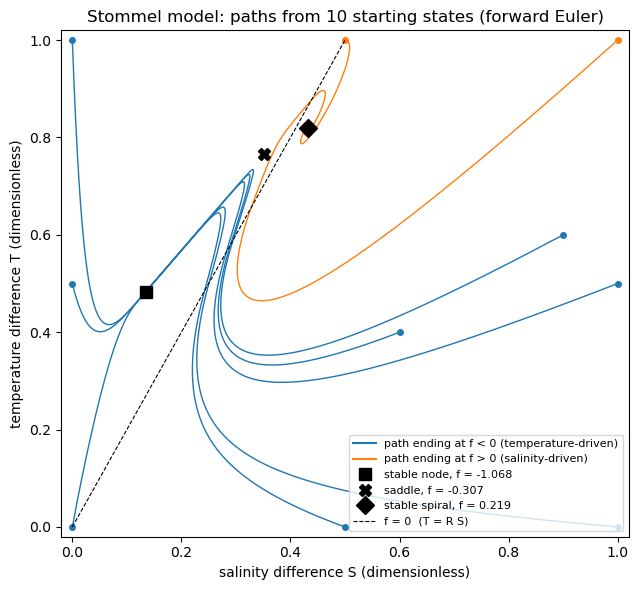

In [8]:
# 6. Figure 2: paths in the S-T plane
fig, ax = plt.subplots(figsize=(6.5, 6))
for k in range(len(paths)):
    S_path, T_path = paths[k]
    if end_f[k] < 0:
        color = "tab:blue"     # ended in the temperature-driven state
    else:
        color = "tab:orange"   # ended in the salinity-driven state
    ax.plot(S_path, T_path, color=color, lw=1)
    ax.plot(S_path[0], T_path[0], "o", color=color, ms=4)

# Lines for the legend only (one entry per color)
ax.plot([], [], color="tab:blue", label="path ending at f < 0 (temperature-driven)")
ax.plot([], [], color="tab:orange", label="path ending at f > 0 (salinity-driven)")

markers = {"stable node": "s", "stable spiral": "D", "saddle": "X"}
for k in range(len(f_equilibria)):
    ax.plot(S_eq[k], T_eq[k], markers.get(types[k], "*"), color="k", ms=9,
            label=f"{types[k]}, f = {f_equilibria[k]:.3f}")

S_line = np.linspace(0, 0.5, 2)
ax.plot(S_line, R * S_line, "k--", lw=0.8, label="f = 0  (T = R S)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_xlabel("salinity difference S (dimensionless)")
ax.set_ylabel("temperature difference T (dimensionless)")
ax.set_title("Stommel model: paths from 10 starting states (forward Euler)")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_stommel_phase_plane.png"), dpi=150)
plt.show()

Finally I print the equilibria next to Stommel's values, where each starting point ended, and the time step check.

In [9]:
# 7. Printing the key numbers
print("Equilibria of Stommel's model (R = 2, delta = 1/6, lambda = 1/5)")
print(f"{'ours f':>9} {'Stommel f':>10} {'T':>7} {'S':>7}   {'eigenvalues':<34} {'our type':<15} Stommel's type")
for k in range(len(f_equilibria)):
    e = eigs_all[k]
    eig_text = f"{e[0].real:+.3f}{e[0].imag:+.3f}i, {e[1].real:+.3f}{e[1].imag:+.3f}i"
    stommel_f = STOMMEL_F[k] if k < len(STOMMEL_F) else float("nan")
    stommel_type = STOMMEL_TYPES[k] if k < len(STOMMEL_TYPES) else "-"
    print(f"{f_equilibria[k]:9.4f} {stommel_f:10.2f} {T_eq[k]:7.4f} {S_eq[k]:7.4f}   "
          f"{eig_text:<34} {types[k]:<15} {stommel_type}")

print()
print("Where each starting point ended (S0, T0) -> final f:")
for k in range(len(starts)):
    print(f"  ({starts[k][0]:.1f}, {starts[k][1]:.1f}) -> f = {end_f[k]:+.4f}")

print()
print(f"dt check: largest end-state difference between dt = {DT} and dt = {DT / 2}: {max_diff_dt:.2e}")
print(f"dt check: largest difference along the paths (same times):        {max_path_diff_dt:.2e}")

Equilibria of Stommel's model (R = 2, delta = 1/6, lambda = 1/5)
   ours f  Stommel f       T       S   eigenvalues                        our type        Stommel's type
  -1.0679      -1.10  0.4836  0.1350   -3.610+0.000i, -0.761+0.000i       stable node     stable node
  -0.3070      -0.30  0.7651  0.3518   -2.849+0.000i, +0.761+0.000i       saddle          saddle
   0.2191       0.23  0.8203  0.4321   -0.912+1.823i, -0.912-1.823i       stable spiral   stable spiral

Where each starting point ended (S0, T0) -> final f:
  (0.0, 0.0) -> f = -1.0679
  (0.5, 0.0) -> f = -1.0679
  (1.0, 0.0) -> f = -1.0679
  (1.0, 0.5) -> f = -1.0679
  (1.0, 1.0) -> f = +0.2191
  (0.5, 1.0) -> f = +0.2191
  (0.0, 1.0) -> f = -1.0679
  (0.0, 0.5) -> f = -1.0679
  (0.6, 0.4) -> f = -1.0679
  (0.9, 0.6) -> f = -1.0679

dt check: largest end-state difference between dt = 0.002 and dt = 0.001: 1.34e-13
dt check: largest difference along the paths (same times):        1.91e-03
